# Aggregate LRT results → Chi-square Comparison (calibration vs test)

Analogous to `LRT/Normalizing_Flows/analyse_LRT_output_ML4PS_style.ipynb` but for the Sparker kernels pipeline.

Scans the output tree for `seed{N}_T.npy` under:
- `<run_tag>/calibration/seed*/` — REF (calibration toys, H0: data from ensemble)
- `<run_tag>/test/seed*/`        — DATA (test toys, target distribution)

**Note on T scaling:** `LRT.py` saves `T = log L_num - log L_den`.
Empirically, the saved T follows χ²(DOF) directly under H0 (median T ≈ median χ²(DOF)).
Use `SCALE_T = 1` to plot T directly with a χ²(DOF) overlay.
`SCALE_T = 2` is available but the chi2 overlay will be scaled accordingly.

In [1]:
import os, glob, math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from matplotlib.patches import Rectangle
from scipy.stats import norm, chi2, beta
from scipy.optimize import minimize_scalar

plt.rcParams["font.family"] = "serif"
plt.style.use('classic')

# --- User config ---
RESULTS_BASE = "/work/gbadarac/MonoJet_NPLM/MonoJet_NPLM_analysis/LRT/Sparker_kernels/results"
RUN_TAG      = "SparKer128_Ntest100000_M100_W0.3_L10000_clip0.0005_wifi_tail_ensemblecomponents128_frozen_weights"

BASE_DIR = os.path.join(RESULTS_BASE, RUN_TAG)
FIG_DIR  = os.path.join(BASE_DIR, "plots")
os.makedirs(FIG_DIR, exist_ok=True)

# Empirically T (saved by LRT.py) ~ chi2(DOF) directly under H0.
# Use SCALE_T = 1 to plot T with chi2(DOF) overlay.
SCALE_T = 1

DOF   = 100    # number of extra parameters in the numerator (kernel coefficients)
NBINS = 30
XMIN  = 0
XMAX  = 400
YMAX  = None

In [2]:
def _collect_mode_T(base_dir, mode, scale=1.0):
    """
    Scan base_dir/<mode>/seed*/seed*_T.npy and return a 1-D float array.
    T values are multiplied by `scale` before returning.
    Prints which seeds are missing or non-finite.
    """
    seed_dirs = sorted(glob.glob(os.path.join(base_dir, mode, "seed*")))
    values = []
    bad = []
    for sd in seed_dirs:
        seed_name = os.path.basename(sd)
        npy_files = glob.glob(os.path.join(sd, f"{seed_name}_T.npy"))
        if not npy_files:
            bad.append((sd, "no T.npy found"))
            continue
        try:
            val = float(np.load(npy_files[0])) * scale
        except Exception as e:
            bad.append((sd, str(e)))
            continue
        if not np.isfinite(val):
            bad.append((sd, f"non-finite T = {val}"))
        else:
            values.append(val)

    print(f"[{mode}] good: {len(values)}, bad/missing: {len(bad)}")
    for sd, reason in bad:
        print(f"  BAD {os.path.basename(sd)}: {reason}")
    return np.asarray(values, dtype=float)

In [3]:
def empirical_Z_from_toys(T_null, T_obs, alternative="greater", alpha=0.32):
    """
    Empirical Z (one-sided) with exact Clopper-Pearson interval on p.
    Returns: Z, Z_plus, Z_minus, p_hat
    """
    T_null = np.asarray(T_null, float)
    B = T_null.size

    if alternative == "greater":
        k = int(np.count_nonzero(T_null >= T_obs))
    elif alternative == "less":
        k = int(np.count_nonzero(T_null <= T_obs))
    else:
        T0 = float(np.median(T_null))
        k  = int(np.count_nonzero(np.abs(T_null - T0) >= np.abs(T_obs - T0)))

    p_hat = (k + 1) / (B + 1)   # add-one estimate (robust at k=0 or k=B)

    if k == 0:
        p_lo = 0.0
        p_hi = beta.ppf(1 - alpha/2, 1, B)
    elif k == B:
        p_lo = beta.ppf(alpha/2, B, 1)
        p_hi = 1.0
    else:
        p_lo = beta.ppf(alpha/2,     k,     B - k + 1)
        p_hi = beta.ppf(1 - alpha/2, k + 1, B - k)

    Z       = norm.ppf(1 - p_hat)
    Z_plus  = norm.ppf(1 - max(1e-16, p_lo))          - Z
    Z_minus = Z - norm.ppf(1 - min(1 - 1e-16, p_hi))
    return Z, Z_plus, Z_minus, p_hat

In [4]:
def fd_bins(x):
    x = np.asarray(x, float)
    if len(x) < 2:
        return 5
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    h   = 2 * iqr / (len(x) ** (1/3) + 1e-12)
    if h <= 0:
        return 10
    return max(5, int(np.ceil((x.max() - x.min()) / h)))


def _safe_xlim(t_all, xmin, xmax, pad_frac=0.05):
    t_all = np.asarray(t_all, float)
    dmin, dmax = np.min(t_all), np.max(t_all)
    if not (np.isfinite(dmin) and np.isfinite(dmax) and dmin < dmax):
        return xmin, xmax
    bad = (xmin is None or xmax is None or xmin >= xmax
           or dmax < xmin or dmin > xmax)
    if bad:
        span = dmax - dmin
        pad  = pad_frac * span if span > 0 else 1.0
        return dmin - pad, dmax + pad
    return xmin, xmax


def plot_T_distributions(
    t_calib, t_test, output_path,
    nbins=None, save=True,
    label1='REF (calibration, H$_0$)',
    label2='DATA (test, target)',
    save_name='T_distribution_Sparker',
    ymax=None,
    title='Sparker kernels LRT',
    xmin=None, xmax=None,
    show_chi2=True,
    dof=100,
    scale_t=1,
):
    """
    Two-panel figure: main histogram + right side-panel with statistics.
    t_calib, t_test : already-scaled T arrays (multiply by SCALE_T before passing)
    scale_t         : used for axis label and chi2 overlay logic
    """
    plt.rcParams["font.family"] = "serif"
    plt.style.use('classic')
    plt.rcParams['patch.edgecolor'] = 'none'
    plt.rcParams['patch.linewidth'] = 0.0

    t_calib = np.asarray(t_calib, float)
    t_test  = np.asarray(t_test,  float)

    fig = plt.figure(figsize=(12, 9))
    fig.patch.set_facecolor('white')
    ax  = fig.add_axes([0.10, 0.12, 0.62, 0.78])
    axp = fig.add_axes([0.76, 0.12, 0.20, 0.78])
    axp.axis('off')

    # --- bins ---
    t_all = np.concatenate([t_calib, t_test]) if len(t_test) else t_calib
    if nbins is None:
        nbins = fd_bins(t_all)
    xmin_eff, xmax_eff = _safe_xlim(t_all, xmin, xmax)
    bins      = np.linspace(xmin_eff, xmax_eff, nbins + 1)
    binswidth = (xmax_eff - xmin_eff) / nbins
    xcenters  = 0.5 * (bins[1:] + bins[:-1])

    # --- calibration histogram (REF) ---
    h1 = ax.hist(
        t_calib,
        weights=np.ones_like(t_calib) / (t_calib.shape[0] * binswidth),
        color="#e186ed", alpha=0.5, bins=bins, label=label1,
        edgecolor='none', linewidth=0
    )
    err1 = np.sqrt(h1[0] / (t_calib.shape[0] * binswidth))
    ax.errorbar(xcenters, h1[0], yerr=err1,
                color="#8a2be2", marker='o', ls='', alpha=0.6,
                markersize=5, capsize=2, elinewidth=0.8)

    # --- chi2 overlay ---
    if show_chi2:
        x_chi2 = np.linspace(max(0.1, xmin_eff), xmax_eff, 500)
        if scale_t == 1:
            y_chi2     = chi2.pdf(x_chi2, df=dof)
            chi2_label = rf'$\chi^2({dof:.1f})$'
        else:
            y_chi2     = 0.5 * chi2.pdf(0.5 * x_chi2, df=dof)
            chi2_label = rf'$\chi^2({dof:.1f})$ (scaled)'
        ax.plot(x_chi2, y_chi2, 'k--', lw=1.5, label=chi2_label)

    # --- test histogram (DATA) ---
    p_emp = Z_emp_val = Z_emp_p = Z_emp_m = np.nan
    if len(t_test):
        h2 = ax.hist(
            t_test,
            weights=np.ones_like(t_test) / (t_test.shape[0] * binswidth),
            color="#68aedc", alpha=0.5, bins=bins, label=label2,
            edgecolor='none', linewidth=0
        )
        err2 = np.sqrt(h2[0] / (t_test.shape[0] * binswidth))
        ax.errorbar(xcenters, h2[0], yerr=err2,
                    color="#004c99", marker='o', ls='', alpha=0.6,
                    markersize=5, capsize=2, elinewidth=0.8)

        T_obs = float(np.median(t_test))
        Z_emp_val, Z_emp_p, Z_emp_m, p_emp = empirical_Z_from_toys(
            t_calib, T_obs, alternative="greater", alpha=0.32
        )

    # --- side panel ---
    panel_fp = font_manager.FontProperties(family='serif', size=20)
    axp.text(0.03, 0.98, rf'$N_{{\mathrm{{calib}}}} = {len(t_calib)}$',
             va='top', ha='left', fontproperties=panel_fp)
    if len(t_test):
        axp.text(0.03, 0.92, rf'$N_{{\mathrm{{test}}}} = {len(t_test)}$',
                 va='top', ha='left', fontproperties=panel_fp)

    SW, GAP = 0.032, 0.012

    def _header(y, color_hex, text):
        axp.add_patch(Rectangle((0.03, y - SW/2), SW, SW,
                                transform=axp.transAxes,
                                facecolor=color_hex, edgecolor='none', alpha=0.5))
        axp.text(0.03 + SW + GAP, y, text,
                 va='center', ha='left', fontproperties=panel_fp, color='black')

    Y_REF_HDR = 0.82
    _header(Y_REF_HDR, "#e186ed", label1)
    axp.text(0.03 + SW + GAP, Y_REF_HDR - 0.065,
             rf'median $= {np.median(t_calib):.1f}$' + '\n'
             + rf'std $= {np.std(t_calib):.1f}$',
             va='top', ha='left', fontproperties=panel_fp)

    if len(t_test):
        Y_DATA_HDR = 0.60
        _header(Y_DATA_HDR, "#68aedc", label2)
        axp.text(0.03 + SW + GAP, Y_DATA_HDR - 0.065,
                 rf'median $= {np.median(t_test):.1f}$' + '\n'
                 + rf'std $= {np.std(t_test):.1f}$',
                 va='top', ha='left', fontproperties=panel_fp)
        axp.text(0.03 + SW + GAP, Y_DATA_HDR - 0.195,
                 rf'p-value $= {p_emp:.4f}$' + '\n'
                 + rf'emp. $Z = {Z_emp_val:.2f}\,^{{+{Z_emp_p:.2f}}}_{{-{Z_emp_m:.2f}}}$',
                 va='top', ha='left', fontproperties=panel_fp)

    legend_fp = font_manager.FontProperties(family='serif', size=16.5)
    ax.legend(ncol=1, loc='upper right', prop=legend_fp, frameon=False,
              handlelength=1.8, borderpad=0.3, labelspacing=0.3)
    xlabel = r'$2t$' if scale_t == 2 else r'$t$'
    ax.set_xlabel(xlabel, fontsize=32, fontname="serif")
    ax.set_ylabel('Probability density', fontsize=28, fontname="serif")
    ax.set_xlim(xmin_eff, xmax_eff)
    if ymax is not None:
        ax.set_ylim(0., ymax)
    ax.tick_params(axis='x', labelsize=22)
    ax.tick_params(axis='y', labelsize=22)
    if title:
        ax.set_title(title, fontsize=28, fontname="serif", pad=14)

    if save:
        os.makedirs(output_path, exist_ok=True)
        base = os.path.join(output_path, save_name)
        fig.savefig(base + ".pdf", bbox_inches="tight", pad_inches=0)
        fig.savefig(base + ".png", dpi=300, bbox_inches="tight",
                    pad_inches=0, facecolor="white")
        print("Saved:", base + ".pdf")
        print("Saved:", base + ".png")
    plt.show()
    plt.close(fig)

In [5]:
t_calib = _collect_mode_T(BASE_DIR, "calibration", scale=SCALE_T)
t_test  = _collect_mode_T(BASE_DIR, "test",        scale=SCALE_T)

print(f"\nScale factor applied: {SCALE_T}")
print(f"Calibration {'2T' if SCALE_T==2 else 'T'}: n={len(t_calib)}, median={np.median(t_calib):.2f}, std={np.std(t_calib):.2f}")
if len(t_test):
    print(f"Test {'2T' if SCALE_T==2 else 'T'}:        n={len(t_test)}, median={np.median(t_test):.2f}, std={np.std(t_test):.2f}")
print(f"\nExpected under Wilks: chi2({DOF}) median={chi2.median(DOF):.1f}, mean={DOF}, std={np.sqrt(2*DOF):.1f}")

[calibration] good: 100, bad/missing: 0
[test] good: 100, bad/missing: 0

Scale factor applied: 1
Calibration T: n=100, median=67.78, std=17.76
Test T:        n=100, median=97.83, std=24.73

Expected under Wilks: chi2(100) median=99.3, mean=100, std=14.1


In [6]:
# Diagnostic: compare calibration quantiles to chi2(DOF)
label = '2T' if SCALE_T == 2 else 'T'
print(f"Calibration {label} vs chi2({DOF}) quantiles:")
print(f"{'quantile':>10}  {'data':>10}  {'chi2':>10}  {'ratio':>8}")
for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
    d = float(np.quantile(t_calib, q))
    c = chi2.ppf(q, DOF)
    print(f"{q:>10.2f}  {d:>10.1f}  {c:>10.1f}  {d/c:>8.2f}")

Calibration T vs chi2(100) quantiles:
  quantile        data        chi2     ratio
      0.10        49.2        82.4      0.60
      0.25        56.9        90.1      0.63
      0.50        67.8        99.3      0.68
      0.75        83.2       109.1      0.76
      0.90        97.0       118.5      0.82


In [7]:
# Fit effective DOF from the calibration null distribution.
# Minimise sum of squared residuals between empirical quantiles and chi2(DOF_eff) quantiles.
# This is more robust than using the median alone and captures the full shape.

_fit_quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]
_empirical_q   = np.quantile(t_calib, _fit_quantiles)

def _dof_residual(dof):
    theoretical = chi2.ppf(_fit_quantiles, dof)
    return np.sum((_empirical_q - theoretical) ** 2)

_result = minimize_scalar(_dof_residual, bounds=(5, 500), method='bounded')
DOF_eff = _result.x

print(f"Nominal DOF (M kernels): {DOF}")
print(f"Effective DOF (fit to calibration null): {DOF_eff:.1f}")
print(f"\nQuantile check — calibration T vs chi2({DOF_eff:.1f}):")
print(f"{'quantile':>10}  {'data':>10}  {'chi2_eff':>10}  {'residual':>10}")
for q, d in zip(_fit_quantiles, _empirical_q):
    c = chi2.ppf(q, DOF_eff)
    print(f"{q:>10.2f}  {d:>10.1f}  {c:>10.1f}  {d - c:>+10.2f}")

Nominal DOF (M kernels): 100
Effective DOF (fit to calibration null): 71.4

Quantile check — calibration T vs chi2(71.4):
  quantile        data    chi2_eff    residual
      0.10        49.2        56.6       -7.37
      0.25        56.9        63.0       -6.18
      0.50        67.8        70.8       -2.97
      0.75        83.2        79.1       +4.12
      0.90        97.0        87.1       +9.95


Saved: /work/gbadarac/MonoJet_NPLM/MonoJet_NPLM_analysis/LRT/Sparker_kernels/results/SparKer128_Ntest100000_M100_W0.3_L10000_clip0.0005_wifi_tail_ensemblecomponents128_frozen_weights/plots/T_distribution_Sparker.pdf
Saved: /work/gbadarac/MonoJet_NPLM/MonoJet_NPLM_analysis/LRT/Sparker_kernels/results/SparKer128_Ntest100000_M100_W0.3_L10000_clip0.0005_wifi_tail_ensemblecomponents128_frozen_weights/plots/T_distribution_Sparker.png


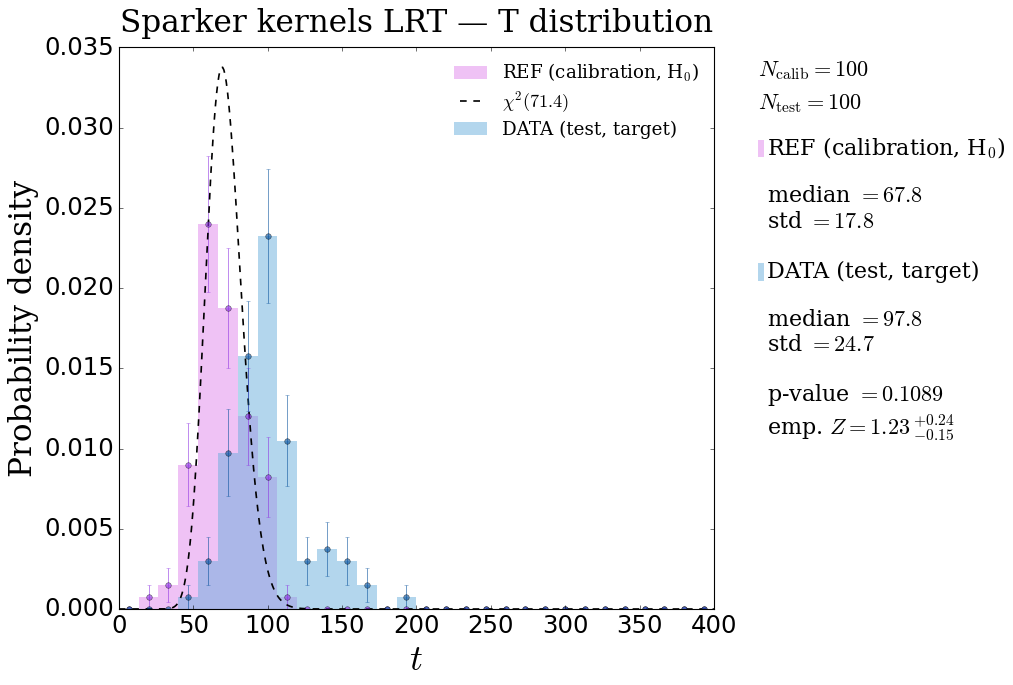

In [8]:
plot_T_distributions(
    t_calib, t_test,
    output_path=FIG_DIR,
    xmin=XMIN, xmax=XMAX, ymax=YMAX, nbins=NBINS,
    save=True,
    label1='REF (calibration, H$_0$)',
    label2='DATA (test, target)',
    save_name='T_distribution_Sparker',
    title='Sparker kernels LRT — T distribution',
    show_chi2=True,
    dof=DOF_eff,
    scale_t=SCALE_T,
)

---
## Signal injection — optimizer sanity check

Inject a large Gaussian bump at (3.0, 0.0), σ=0.3, N=10 000 into the test data (CALIBRATION=0).  
Compare T for **default weights** (Gaussian prior) vs **free weights** (no prior) against the existing calibration null (reused from above).

Key question: do both modes give T >> null when a clear signal is present?

In [20]:
# --- Injection test config ---
# Each mode uses its own matching calibration (c-1) as null and the injection run (c-0) as signal.
#
# Default weights:
#   null  → SparKer60_..._wifi_fix_normalization            /calibration/
#   test  → SparKer60_..._wifi_fix_normalization_inject_... /test/
#
# Free weights:
#   null  → SparKer60_..._wifi_fix_normalization_free_weights            /calibration/
#   test  → SparKer60_..._wifi_fix_normalization_free_weights_inject_... /test/

INJECT_SUFFIX        = "_inject_loc3.0_0.0_s0.3_n10000"
TAG_DEFAULT_NULL     = RUN_TAG                                   # existing default run
TAG_FREE_NULL        = RUN_TAG + "_free_weights"                 # existing free-weights run
TAG_DEFAULT_INJ      = RUN_TAG + INJECT_SUFFIX
TAG_FREE_INJ         = RUN_TAG + "_free_weights" + INJECT_SUFFIX

DIR_DEFAULT_NULL = os.path.join(RESULTS_BASE, TAG_DEFAULT_NULL)
DIR_FREE_NULL    = os.path.join(RESULTS_BASE, TAG_FREE_NULL)
DIR_DEFAULT_INJ  = os.path.join(RESULTS_BASE, TAG_DEFAULT_INJ)
DIR_FREE_INJ     = os.path.join(RESULTS_BASE, TAG_FREE_INJ)

# Load matching calibration nulls
print("=== Default-weights mode ===")
t_null_default = _collect_mode_T(DIR_DEFAULT_NULL, "calibration", scale=SCALE_T)
t_inj_default  = _collect_mode_T(DIR_DEFAULT_INJ,  "test",        scale=SCALE_T)

print("\n=== Free-weights mode ===")
t_null_free    = _collect_mode_T(DIR_FREE_NULL, "calibration", scale=SCALE_T)
t_inj_free     = _collect_mode_T(DIR_FREE_INJ,  "test",        scale=SCALE_T)

print(f"\nDefault weights: null median={np.median(t_null_default):.1f}, inj median={np.median(t_inj_default):.1f}")
print(f"Free weights:    null median={np.median(t_null_free):.1f}, inj median={np.median(t_inj_free):.1f}")

X_MIN = None
XMAX = 200500

=== Default-weights mode ===
[calibration] good: 100, bad/missing: 0
[test] good: 100, bad/missing: 0

=== Free-weights mode ===
[calibration] good: 100, bad/missing: 0
[test] good: 100, bad/missing: 0

Default weights: null median=65.1, inj median=174890.4
Free weights:    null median=66.7, inj median=174910.6


In [ ]:
# One panel per weight mode: matching null (calibration) vs injection (test)
# Plots saved in the injection run's own plots/ folder.
# Adjust XMAX in the setup cell to cover the injection T range (~180000).

FIG_DIR_DEFAULT_INJ = os.path.join(DIR_DEFAULT_INJ, "plots")
FIG_DIR_FREE_INJ    = os.path.join(DIR_FREE_INJ,    "plots")

# --- Default weights ---
plot_T_distributions(
    t_null_default, t_inj_default,
    output_path=FIG_DIR_DEFAULT_INJ,
    xmin=XMIN, xmax=XMAX, ymax=YMAX, nbins=NBINS,
    save=True,
    label1=r"Null — default weights (H$_0$)",
    label2=r"Injection — default weights",
    save_name="T_injection_default_weights",
    title=r"Injection sanity check — default weights, bump $(3.0,\,0.0)$, $\sigma=0.3$, $N=10^4$",
    show_chi2=True,
    dof=DOF_eff,
    scale_t=SCALE_T,
)

# --- Free weights ---
plot_T_distributions(
    t_null_free, t_inj_free,
    output_path=FIG_DIR_FREE_INJ,
    xmin=XMIN, xmax=XMAX, ymax=YMAX, nbins=NBINS,
    save=True,
    label1=r"Null — free weights (H$_0$)",
    label2=r"Injection — free weights",
    save_name="T_injection_free_weights",
    title=r"Injection sanity check — free weights, bump $(3.0,\,0.0)$, $\sigma=0.3$, $N=10^4$",
    show_chi2=True,
    dof=DOF_eff,
    scale_t=SCALE_T,
)

### DEN weight movement: injection vs no-injection

Do the denominator WiFi weights actually shift when trained on injected data?  
Compare Δw = w_den − w_init across seeds for: no-injection default, injection default, injection free weights.

In [22]:
def collect_weight_shifts(base_dir, mode="test"):
    """
    For each seed in base_dir/<mode>/seed*/, load den_weights and init_weights,
    return array of shape (n_seeds, n_weights) of Δw = w_den - w_init.
    """
    seed_dirs = sorted(glob.glob(os.path.join(base_dir, mode, "seed*")))
    deltas = []
    for sd in seed_dirs:
        name = os.path.basename(sd)
        f_den  = os.path.join(sd, f"{name}_den_weights.npy")
        f_init = os.path.join(sd, f"{name}_init_weights.npy")
        if not (os.path.exists(f_den) and os.path.exists(f_init)):
            continue
        w_den  = np.load(f_den).ravel()
        w_init = np.load(f_init).ravel()
        deltas.append(w_den - w_init)
    return np.array(deltas)   # shape: (n_seeds, n_weights)


dw_default_noinj = collect_weight_shifts(DIR_DEFAULT_NULL, "test")
dw_default_inj   = collect_weight_shifts(DIR_DEFAULT_INJ,  "test")
dw_free_inj      = collect_weight_shifts(DIR_FREE_INJ,     "test")

print(f"Seeds loaded — no-inj default: {len(dw_default_noinj)}, inj default: {len(dw_default_inj)}, inj free: {len(dw_free_inj)}")
print(f"\nMean max|Δw| per seed:")
print(f"  No injection (default): {np.mean(np.max(np.abs(dw_default_noinj), axis=1)):.4f}")
print(f"  Injection (default):    {np.mean(np.max(np.abs(dw_default_inj),   axis=1)):.4f}")
print(f"  Injection (free w):     {np.mean(np.max(np.abs(dw_free_inj),      axis=1)):.4f}")

Seeds loaded — no-inj default: 100, inj default: 100, inj free: 100

Mean max|Δw| per seed:
  No injection (default): 0.0748
  Injection (default):    0.0748
  Injection (free w):     0.0990


Saved: /work/gbadarac/MonoJet_NPLM/MonoJet_NPLM_analysis/LRT/Sparker_kernels/results/SparKer60_Ntest100000_M100_W0.3_L10000_clip0.0005_wifi_fix_normalization/plots/den_weight_init_vs_final_noinj_default.png


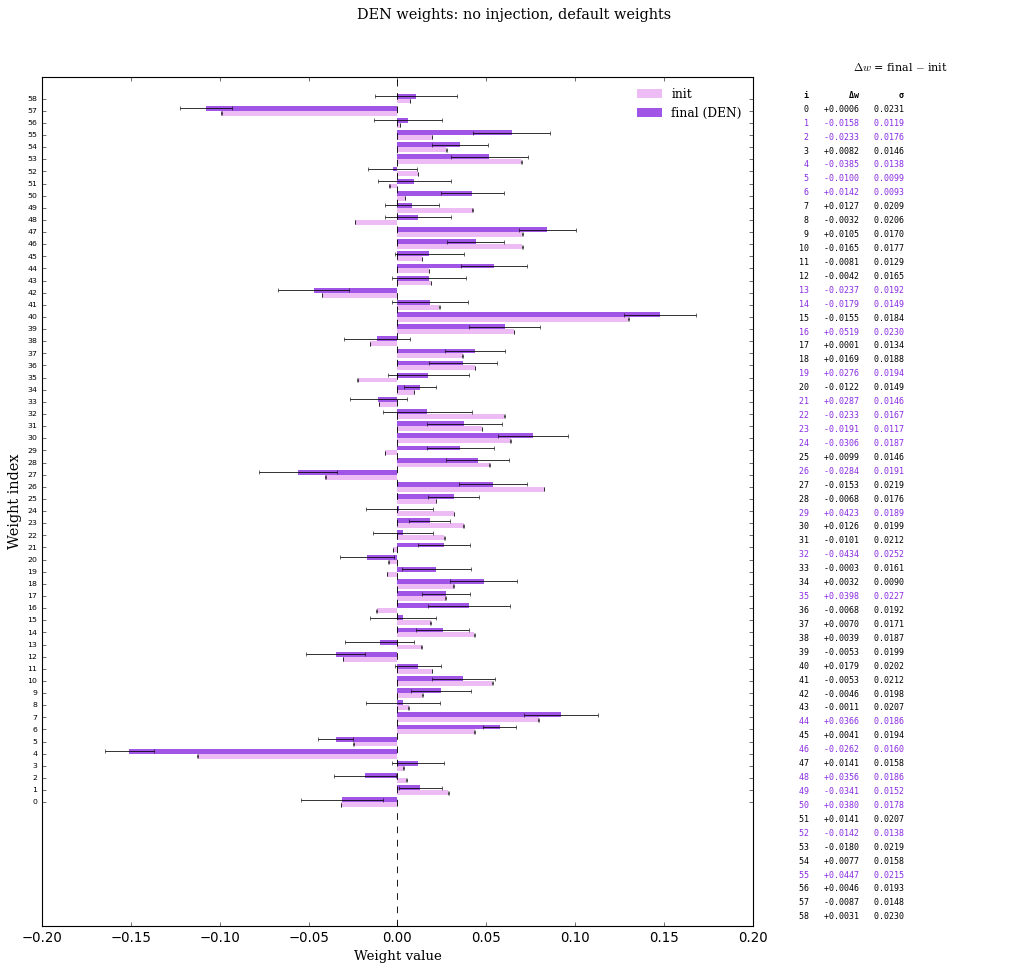

Saved: /work/gbadarac/MonoJet_NPLM/MonoJet_NPLM_analysis/LRT/Sparker_kernels/results/SparKer60_Ntest100000_M100_W0.3_L10000_clip0.0005_wifi_fix_normalization_free_weights/plots/den_weight_init_vs_final_noinj_free.png


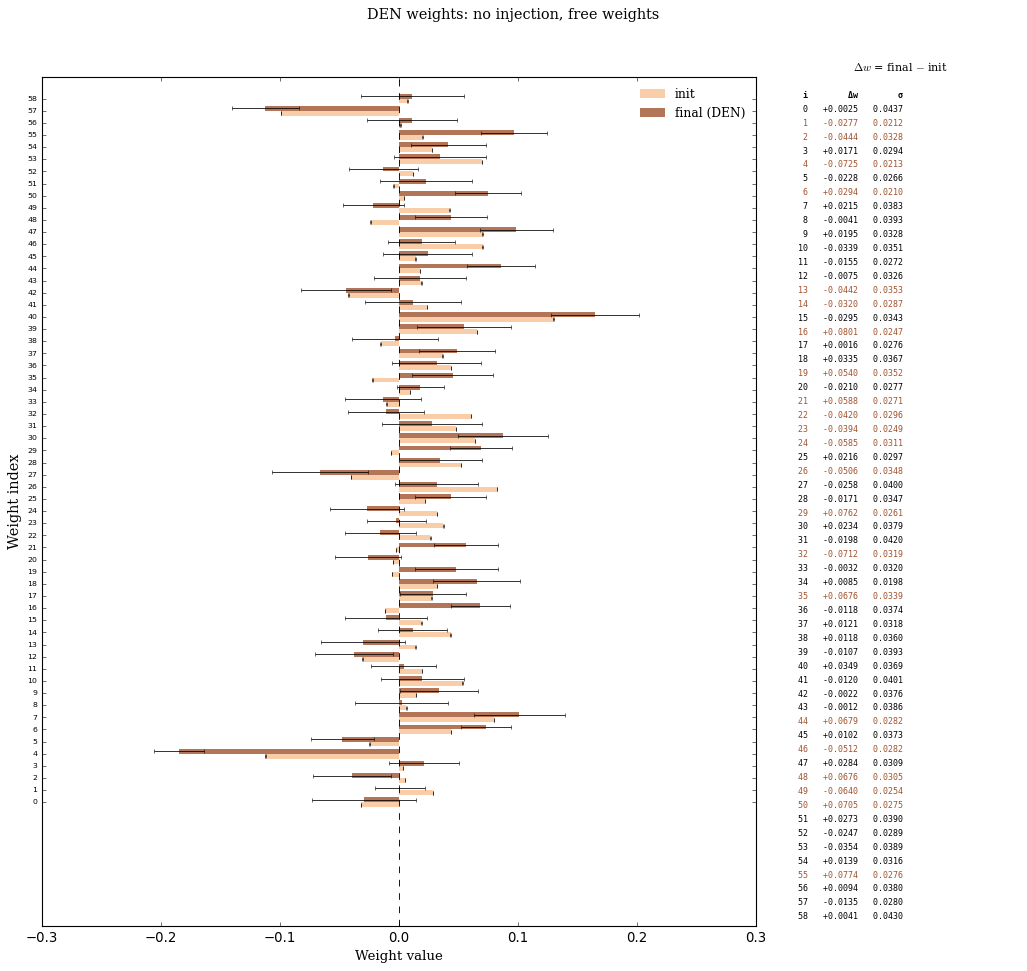

Saved: /work/gbadarac/MonoJet_NPLM/MonoJet_NPLM_analysis/LRT/Sparker_kernels/results/SparKer60_Ntest100000_M100_W0.3_L10000_clip0.0005_wifi_fix_normalization_inject_loc3.0_0.0_s0.3_n10000/plots/den_weight_init_vs_final_inj_default.png


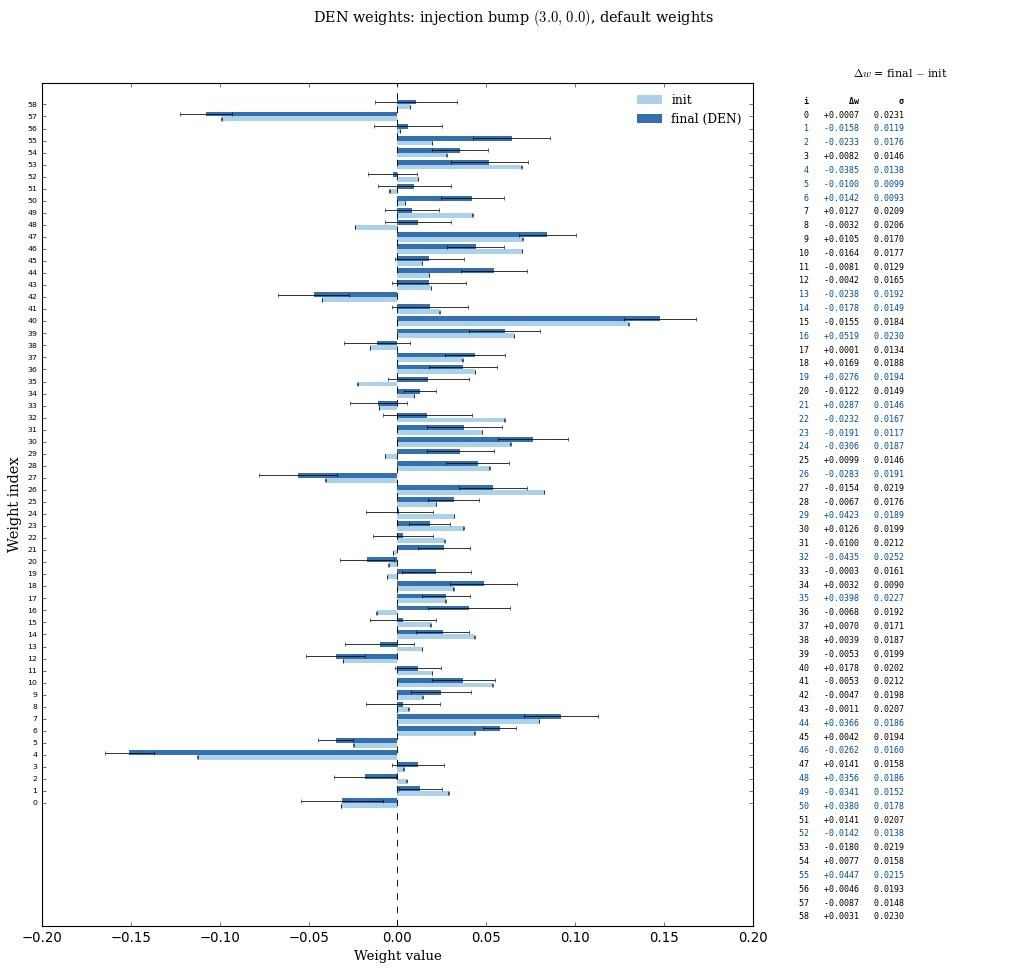

Saved: /work/gbadarac/MonoJet_NPLM/MonoJet_NPLM_analysis/LRT/Sparker_kernels/results/SparKer60_Ntest100000_M100_W0.3_L10000_clip0.0005_wifi_fix_normalization_free_weights_inject_loc3.0_0.0_s0.3_n10000/plots/den_weight_init_vs_final_inj_free.png


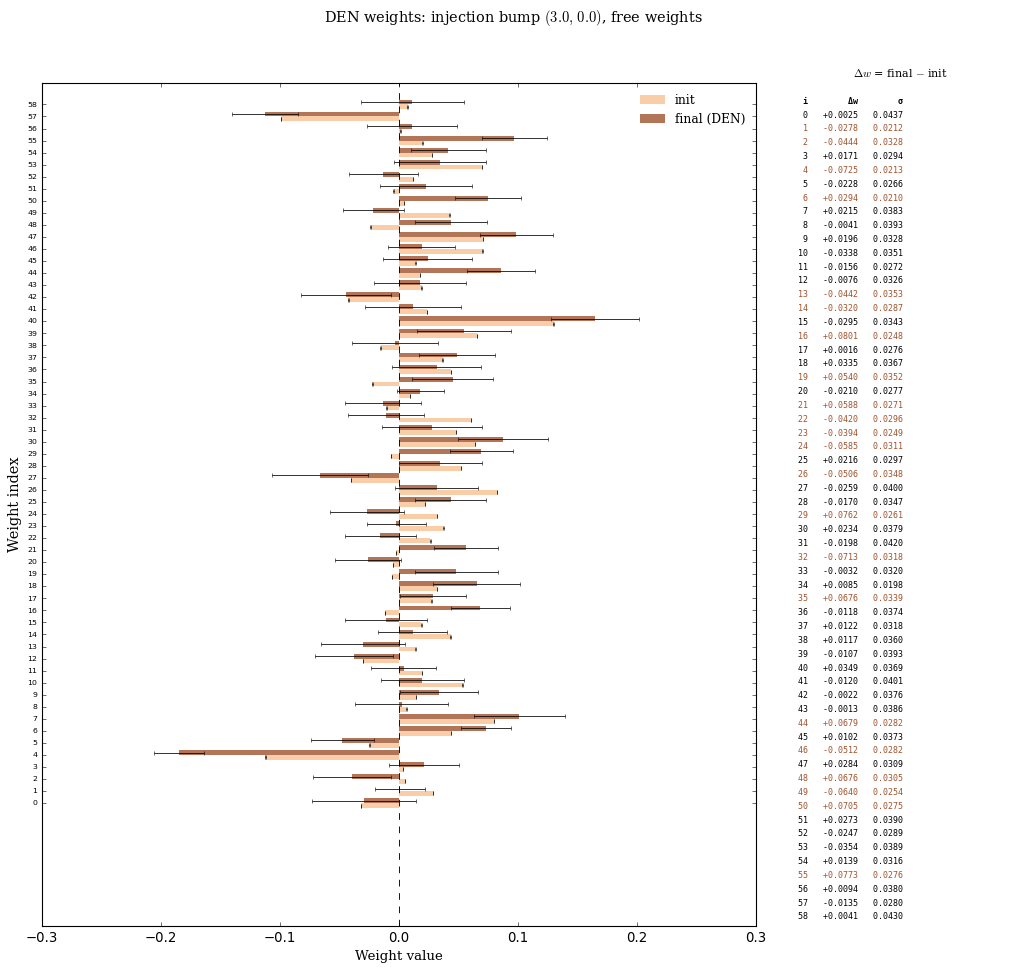

In [26]:
def load_init_final(base_dir, mode="test"):
    seed_dirs = sorted(glob.glob(os.path.join(base_dir, mode, "seed*")))
    inits, finals = [], []
    for sd in seed_dirs:
        name = os.path.basename(sd)
        f_init = os.path.join(sd, f"{name}_init_weights.npy")
        f_den  = os.path.join(sd, f"{name}_den_weights.npy")
        if not (os.path.exists(f_init) and os.path.exists(f_den)):
            continue
        inits.append(np.load(f_init).ravel())
        finals.append(np.load(f_den).ravel())
    return np.array(inits), np.array(finals)


def plot_weight_init_vs_final(w_init, w_fin, title, save_path, c_init, c_fin):
    n_w   = w_init.shape[1]
    y_idx = np.arange(n_w)
    mu_i, s_i = w_init.mean(axis=0), w_init.std(axis=0)
    mu_f, s_f = w_fin.mean(axis=0),  w_fin.std(axis=0)
    dw        = mu_f - mu_i
    dw_std    = np.sqrt(s_i**2 + s_f**2)

    fig, (ax_bar, ax_tab) = plt.subplots(
        1, 2, figsize=(13, 12),
        gridspec_kw={"width_ratios": [3, 1]},
        sharey=True,
    )
    fig.patch.set_facecolor('white')

    # ── Bar chart ────────────────────────────────────────────────────────
    ax_bar.set_facecolor('white')
    ax_bar.barh(y_idx,       mu_i, xerr=s_i, height=0.4,
                color=c_init, alpha=0.55, label="init",
                error_kw=dict(elinewidth=0.7, capsize=2))
    ax_bar.barh(y_idx + 0.4, mu_f, xerr=s_f, height=0.4,
                color=c_fin,  alpha=0.8,  label="final (DEN)",
                error_kw=dict(elinewidth=0.7, capsize=2))
    ax_bar.axvline(0, color='k', lw=0.8, ls='--')
    ax_bar.set_yticks(y_idx + 0.2)
    ax_bar.set_yticklabels([str(i) for i in y_idx], fontsize=7)
    ax_bar.set_ylabel("Weight index", fontsize=13, fontname="serif")
    ax_bar.set_xlabel("Weight value", fontsize=12, fontname="serif")
    ax_bar.legend(prop=font_manager.FontProperties(family='serif', size=11), frameon=False)

    # ── Table: idx | Δw | std ────────────────────────────────────────────
    ax_tab.axis('off')
    fp = font_manager.FontProperties(family='monospace', size=7.5)
    row_h = 1.0 / (n_w + 2)

    # header
    ax_tab.text(0.05, 1.0 - row_h,
                f"{'i':>3}  {'Δw':>8}  {'σ':>7}",
                va='top', ha='left', transform=ax_tab.transAxes,
                fontproperties=fp, fontweight='bold')

    for i, (d, s) in enumerate(zip(dw, dw_std)):
        y_pos = 1.0 - (i + 2) * row_h
        color = c_fin if abs(d) > s else 'black'
        ax_tab.text(0.05, y_pos,
                    f"{i:>3}  {d:>+8.4f}  {s:>7.4f}",
                    va='top', ha='left', transform=ax_tab.transAxes,
                    fontproperties=fp, color=color)

    ax_tab.set_title(r"$\Delta w$ = final $-$ init", fontsize=10, fontname="serif")

    fig.suptitle(title, fontsize=13, fontname="serif", y=1.01)
    fig.tight_layout()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=200, bbox_inches="tight", facecolor="white")
    fig.savefig(save_path.replace(".png", ".pdf"), bbox_inches="tight")
    print("Saved:", save_path)
    plt.show()
    plt.close(fig)


inits_noinj_def,  finals_noinj_def  = load_init_final(DIR_DEFAULT_NULL, "test")
inits_noinj_free, finals_noinj_free = load_init_final(DIR_FREE_NULL,    "test")
inits_inj_def,    finals_inj_def    = load_init_final(DIR_DEFAULT_INJ,  "test")
inits_inj_free,   finals_inj_free   = load_init_final(DIR_FREE_INJ,     "test")

FIG_DIR_FREE_NULL_PLOTS = os.path.join(DIR_FREE_NULL, "plots")

configs = [
    (inits_noinj_def,  finals_noinj_def,
     "DEN weights: no injection, default weights",
     os.path.join(FIG_DIR,                 "den_weight_init_vs_final_noinj_default.png"),
     "#e186ed", "#8a2be2"),
    (inits_noinj_free, finals_noinj_free,
     "DEN weights: no injection, free weights",
     os.path.join(FIG_DIR_FREE_NULL_PLOTS, "den_weight_init_vs_final_noinj_free.png"),
     "#f4a460", "#a0522d"),
    (inits_inj_def,    finals_inj_def,
     r"DEN weights: injection bump $(3.0,\,0.0)$, default weights",
     os.path.join(FIG_DIR_DEFAULT_INJ,     "den_weight_init_vs_final_inj_default.png"),
     "#68aedc", "#004c99"),
    (inits_inj_free,   finals_inj_free,
     r"DEN weights: injection bump $(3.0,\,0.0)$, free weights",
     os.path.join(FIG_DIR_FREE_INJ,        "den_weight_init_vs_final_inj_free.png"),
     "#f4a460", "#a0522d"),
]

for w_i, w_f, title, path, c_i, c_f in configs:
    plot_weight_init_vs_final(w_i, w_f, title, path, c_i, c_f)

---
## Clipping diagnostic — ensemble LRT

How many of the M=100 numerator kernel coefficients saturate `clip_tau` under H₀?  
A large `n_at_clip` means the regularisation is reducing the effective DOF, explaining why DOF_eff < 100.

In [9]:
def collect_n_at_clip(base_dir, mode, clip_tau=0.0005):
    """
    For each seed in base_dir/<mode>/seed*/, load seed*_coeffs.npy and count
    how many kernel coefficients saturate the clip boundary.
    Returns array of shape (n_seeds,) with n_at_clip per seed.
    """
    seed_dirs = sorted(glob.glob(os.path.join(base_dir, mode, "seed*")))
    counts = []
    for sd in seed_dirs:
        name = os.path.basename(sd)
        f = os.path.join(sd, f"{name}_coeffs.npy")
        if not os.path.exists(f):
            continue
        coeffs = np.load(f).ravel()
        n_sat = int(np.sum(np.abs(coeffs) >= clip_tau * 0.999))
        counts.append(n_sat)
    return np.array(counts)


# Ensemble LRT calibration results (free WiFi weights, matching the null used above)
ENSEMBLE_CALIB_TAG = "SparKer128_Ntest100000_M100_W0.3_L10000_clip0.0005_wifi_tail_ensemblecomponents128_frozen_weights"
DIR_ENSEMBLE_CALIB = os.path.join(RESULTS_BASE, ENSEMBLE_CALIB_TAG)

clip_tau_val = 0.0005
n_at_clip_calib = collect_n_at_clip(DIR_ENSEMBLE_CALIB, "calibration", clip_tau=clip_tau_val)

print(f"Ensemble calibration toys: {len(n_at_clip_calib)} seeds")
print(f"n_at_clip  mean = {n_at_clip_calib.mean():.1f}")
print(f"           std  = {n_at_clip_calib.std():.1f}")
print(f"           min  = {n_at_clip_calib.min()},  max = {n_at_clip_calib.max()}")
print(f"\nEffective DOF estimate from clipping: {DOF} - {n_at_clip_calib.mean():.1f} = {DOF - n_at_clip_calib.mean():.1f}")
print(f"DOF_eff from chi2 quantile fit:       {DOF_eff:.1f}")

Ensemble calibration toys: 100 seeds
n_at_clip  mean = 31.4
           std  = 4.2
           min  = 22,  max = 41

Effective DOF estimate from clipping: 100 - 31.4 = 68.6
DOF_eff from chi2 quantile fit:       71.4


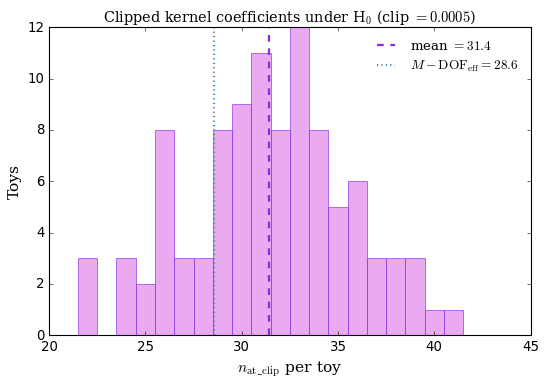

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bins_clip = np.arange(n_at_clip_calib.min() - 0.5, n_at_clip_calib.max() + 1.5, 1)
ax.hist(n_at_clip_calib, bins=bins_clip, color="#e186ed", alpha=0.7, edgecolor="#8a2be2", linewidth=0.8)
ax.axvline(n_at_clip_calib.mean(), color="#8a2be2", lw=2, ls='--',
           label=rf'mean $= {n_at_clip_calib.mean():.1f}$')
ax.axvline(DOF - DOF_eff, color='steelblue', lw=2, ls=':',
           label=rf'$M - \mathrm{{DOF}}_\mathrm{{eff}} = {DOF - DOF_eff:.1f}$')

ax.set_xlabel(r'$n_\mathrm{at\_clip}$ per toy', fontsize=14, fontname='serif')
ax.set_ylabel('Toys', fontsize=14, fontname='serif')
ax.set_title(rf'Clipped kernel coefficients under H$_0$ (clip $= {clip_tau_val}$)', fontsize=13, fontname='serif')
ax.legend(prop=font_manager.FontProperties(family='serif', size=12), frameon=False)
ax.tick_params(labelsize=12)

fig.tight_layout()
clip_fig_path = os.path.join(DIR_ENSEMBLE_CALIB, "plots")
os.makedirs(clip_fig_path, exist_ok=True)
fig.savefig(os.path.join(clip_fig_path, "n_at_clip_calibration.png"), dpi=200, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(clip_fig_path, "n_at_clip_calibration.pdf"), bbox_inches='tight')
plt.show()
plt.close(fig)